# 2장 1강: 시계열 데이터의 이해와 정상성 진단

## 실습 목표

이번 실습에서는 **Bike Sharing Demand** 데이터를 이용해 시간에 따른 자전거 대여량 변화를 확인합니다.

- 시계열 데이터에서 **시간 순서가 중요한 이유**를 확인합니다.
- 선 그래프와 시계열 분해를 이용해 **Trend / Seasonality / Residual**을 확인합니다.
- 이동평균을 이용해 데이터의 평균적인 수준 변화를 살펴봅니다.
- **ADF Test**를 이용해 정상성을 진단합니다.
- 정상성을 만족하지 않는 경우 **1차 차분**을 적용하고 ADF Test를 다시 수행합니다.

> 이 실습에서는 교안에서 다룬 내용만 사용합니다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- statsmodels
- 데이터: `Bike_Sharing_Demand.csv`

### 주요 컬럼

| 컬럼 | 의미 |
|---|---|
| `datetime` | 자전거 대여 기록 시각 |
| `casual` | 비등록 사용자의 대여 수 |
| `registered` | 등록 사용자의 대여 수 |
| `count` | 전체 자전거 대여 수 |

`count`는 `casual + registered`로 구성된 전체 대여량입니다.

In [1]:
# 시계열 데이터: 시간의 흐름에 따라 순서대로 관측한 데이터
# -> 1시간 뒤 인구, 2시간 뒤 인구, 강수량, 하천 수위 등

# 관측 간격(Frequancy): 연속한 관측이 어떤 시간 단위로 기옥되었는지?
# 시간별, 일별, 주별, 월별 등

# 시차(Lag): 두 관측 시점 사이에 몇 관측의 간격만큼 떨어져 있는지
# Lag1은 이전 관측, Lag7은 7개 타임 전을 의미(시간별이면 1시간 전, 7시간 전을 의미)

# 자기상관: 같은 시계열의 값과 일정한 시차만큼 이전 값 사이의 상관관계
# -> 여름철 기온이 높은날과 다음날 같은 시간에도 높은 기온이 나타나는 경향이 있다면 자기상관을 예상할 수 있다.
# -> 단, 여러 날의 값을 비교해야한다.(1~2가지의 케이스만 보고 결정하면 안된다.)

# 추세(Trend): 시간의 흐름에 따라 장기적인 증가 또는 감소 흐름을 보이는지?
# -> 주문량이 월별로 100,110,105,120,135였다면 점진적으로 우상향 하는 추세가 있다.(추세선)

# 계절성(Seasonality): 일정한 시간 간격을 두고 반복되는 패턴
# -> 매주 금요일마다 치킨 배달 수가 늘어난다면 주간 계절성으로 볼 수 있다.

# 잔차(Residual): 관측된 데이터를 추세나 계절성 등으로 설명한 뒤 남은 변동
# -> 어느 달 매출이 152만원, 추세가 130, 계절 성분이 20이라면 잔차는 2이다. 패턴보다 2만큼 더 관측되었다.
# -> 2의 원인은 추가적으로 확인이 필요

# 이동 평균: 일정한 구간의 평균을 구하고 그 구간을 이동시키면서 반복 계산 
# -> 단기적인 변동을 완화화여 평균 수준을 보려고 이동 평균을 사용한다.
# -> 낙차 폭이 매우 크고 잦은 데이터의 추세를 알기 위해 이용(지진계, 거짓말탐지기 등)

# 정상성: 시간이 달라도 시계열의 통상적인 성질이 변하지 않는 성질
# -> 101, 98, 102, 99, 96, 104 처럼 100 주변에서 비슷하게 오르내리면 정상성에 가깝다라고 표현할 수 있다.
# -> 일반적으로 예상할 수 있는 성질

# 비정상 시계열: 평균, 분산 등의 통계적 특성이 시간에 따라 달라지는 시계열
# -> 꾸준하게 회원 가입 수가 늘고있는 이커머스 페이지에서 올해 여름에 갑자기 추가로 회원가입 수가 증가했다면
# 기존에 추세와 계절성과 다른 부분이 발생할 수 있다.

# 차분(1차): 현재 값에서 이전 값을 빼, 시점 사이의 변화량으로 바꾸는 방법
# -> 일별 사용자 수가 10000, 10300, 10500, 10400명이면 1차 차분은 300, 200, -100

# 차분(2차): 1차 차분값에 다시 1차 차분을 적용한 값
# -> 월별 가입자가 100, 110, 125, 135명이면 1차 차분은 10, 15, 10명이고 2차 차분은 +5, -5다.

## 실습 준비

먼저 데이터를 불러온 뒤 다음 내용을 확인합니다.

1. 데이터 크기와 상위 행
2. 주요 컬럼의 자료형
3. 결측치
4. `datetime`을 날짜/시간 자료형으로 변환
5. 시간 순서대로 정렬
6. 일별·월별 대여량 데이터 준비

> 일별·월별 집계 코드는 이후 시계열 실습을 위한 **준비 코드**로 제공됩니다.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

bike = pd.read_csv("Bike_Sharing_Demand.csv")

print("데이터 크기:", bike.shape)
display(bike.head())

print("\n[자료형]")
display(bike[["datetime", "casual", "registered", "count"]].dtypes.to_frame("dtype"))

print("\n[결측치]")
display(bike[["datetime", "casual", "registered", "count"]].isna().sum().to_frame("missing"))

데이터 크기: (10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1



[자료형]


,dtype
datetime,str
casual,int64
registered,int64
count,int64



[결측치]


,missing
datetime,0
casual,0
registered,0
count,0


In [3]:
# datetime 변환 및 시간 순서 정렬
bike["datetime"] = pd.to_datetime(bike["datetime"])
bike = bike.sort_values("datetime").reset_index(drop=True)

print("최초 시각:", bike["datetime"].min())
print("마지막 시각:", bike["datetime"].max())
display(bike.head())

최초 시각: 2011-01-01 00:00:00
마지막 시각: 2012-12-19 23:00:00


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [4]:
# 일별 시계열 준비
bike["date"] = bike["datetime"].dt.date

daily = (bike.groupby("date", as_index=False)[["count", "casual", "registered"]].sum())

daily["date"] = pd.to_datetime(daily["date"])

# 월별 시계열 준비
bike["month"] = bike["datetime"].dt.to_period("M").astype(str)

monthly = (bike.groupby("month", as_index=False)["count"].sum())

monthly["month"] = pd.to_datetime(monthly["month"])

print("[일별 데이터]")
display(daily.head())

print("\n[월별 데이터]")
display(monthly.head())

[일별 데이터]


,date,count,casual,registered
0,2011-01-01,985,331,654
1,2011-01-02,801,131,670
2,2011-01-03,1349,120,1229
3,2011-01-04,1562,108,1454
4,2011-01-05,1600,82,1518



[월별 데이터]


,month,count
0,2011-01-01,23552
1,2011-02-01,32844
2,2011-03-01,38735
3,2011-04-01,50517
4,2011-05-01,79713


In [5]:
min_date = bike["date"].min()
max_date = bike["date"].max()

all_day = pd.date_range(start=min_date, end=max_date, freq="D")
missing_days = all_day.difference(pd.to_datetime(bike["date"].unique()))

print("전체", len(all_day))
print("누락", len(missing_days))
print(missing_days)

전체 719
누락 263
DatetimeIndex(['2011-01-20', '2011-01-21', '2011-01-22', '2011-01-23',
               '2011-01-24', '2011-01-25', '2011-01-26', '2011-01-27',
               '2011-01-28', '2011-01-29',
               ...
               '2012-11-21', '2012-11-22', '2012-11-23', '2012-11-24',
               '2012-11-25', '2012-11-26', '2012-11-27', '2012-11-28',
               '2012-11-29', '2012-11-30'],
              dtype='datetime64[s]', length=263, freq=None)


---

# 필수 1. 시간 흐름과 시계열 패턴 확인

## 배경

시계열 데이터는 값 자체뿐만 아니라 **언제 관측되었는지와 어떤 순서로 나타났는지**가 중요합니다.

Bike Sharing Demand 데이터의 전체 대여량 `count`를 시간 순서대로 확인하고, 월별 대여량을 **Trend / Seasonality / Residual**로 나누어 살펴봅니다.

## 문제 1. 일별 대여량을 시간 순서대로 확인하세요.

### 요구사항

1. `daily["date"]`를 x축, `daily["count"]`를 y축으로 선 그래프를 그립니다.
2. 그래프 제목을 `Daily Bike Rentals`로 설정합니다.
3. 시간의 흐름에 따라 대여량의 전반적인 수준이 어떻게 변화하는지 설명합니다.

### 확인 포인트

- 시계열 그래프에서는 시간 순서를 유지했는가?
- 단순히 개별 값만 보는 것이 아니라 전체적인 흐름을 확인했는가?

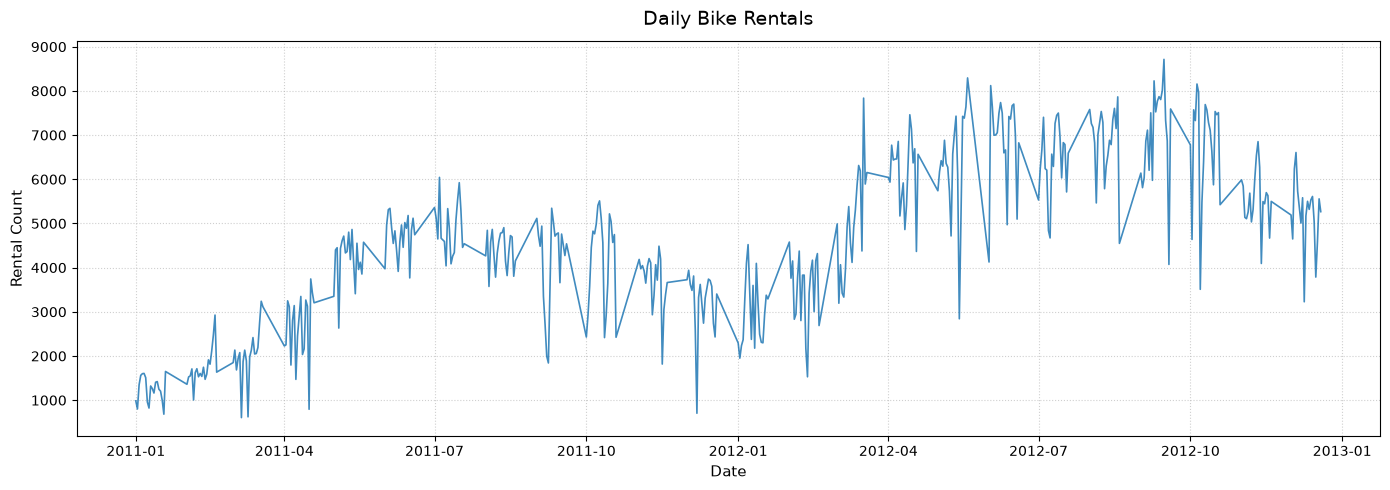

In [6]:
# TODO
# daily["date"]와 daily["count"]를 이용해 선 그래프를 그려보세요.
import matplotlib.pyplot as plt
import pandas as pd

# 1. date 컬럼 datetime 변환 및 시간순 정렬 확인
daily["date"] = pd.to_datetime(daily["date"])
daily = daily.sort_values("date").reset_index(drop=True)

# 2. 선 그래프 시각화
plt.figure(figsize=(14, 5))
plt.plot(
    daily["date"],
    daily["count"],
    color="tab:blue",
    linewidth=1.2,
    alpha=0.85,
)
plt.title("Daily Bike Rentals", fontsize=14, pad=12)
plt.xlabel("Date", fontsize=11)
plt.ylabel("Rental Count", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

### Q1. 왜 `daily` 데이터를 무작위로 섞지 않고 날짜 순서대로 확인해야 할까요?

##### 수준은 값이 대체로 어느 높이에서 움직이는지
##### 변동은 그 수준 주변에서 값이 얼마나 오르내리는지

##### 시계열에서 결측과 시간 누락은 다른 개념으로 반드시 시간 누락은 체크해야한다.
##### 관측된 일별 대여량은 2011년보다 2012년에 높은 수준을 보이며, 변동은 상승과 하락이 큰 편이다.
##### 비교적 여름철에 상승하고 겨울철에 하락하는 모습을 보이지만 시간 누락이 있기 때문에 유의하여 해석해야한다.


**답변:**  
- 시계열 데이터는 시간의 흐름자체가 중요한 정보이므로 무작위로 섞으면 look ahead가 발생할 수 있다.

## 문제 2. 월별 대여량을 시계열 분해하세요.

### 요구사항

1. `monthly`의 `month`를 인덱스로 설정합니다.
2. `seasonal_decompose()`를 사용합니다.
3. `model="additive"`를 사용합니다.
4. 월별 데이터의 1년 반복 주기를 확인하기 위해 `period=12`를 사용합니다.
5. 결과에서 `Observed`, `Trend`, `Seasonal`, `Residual`을 확인합니다.

### 확인 포인트

- `period=12`의 의미를 이해했는가?
- Trend / Seasonality / Residual을 구분할 수 있는가?

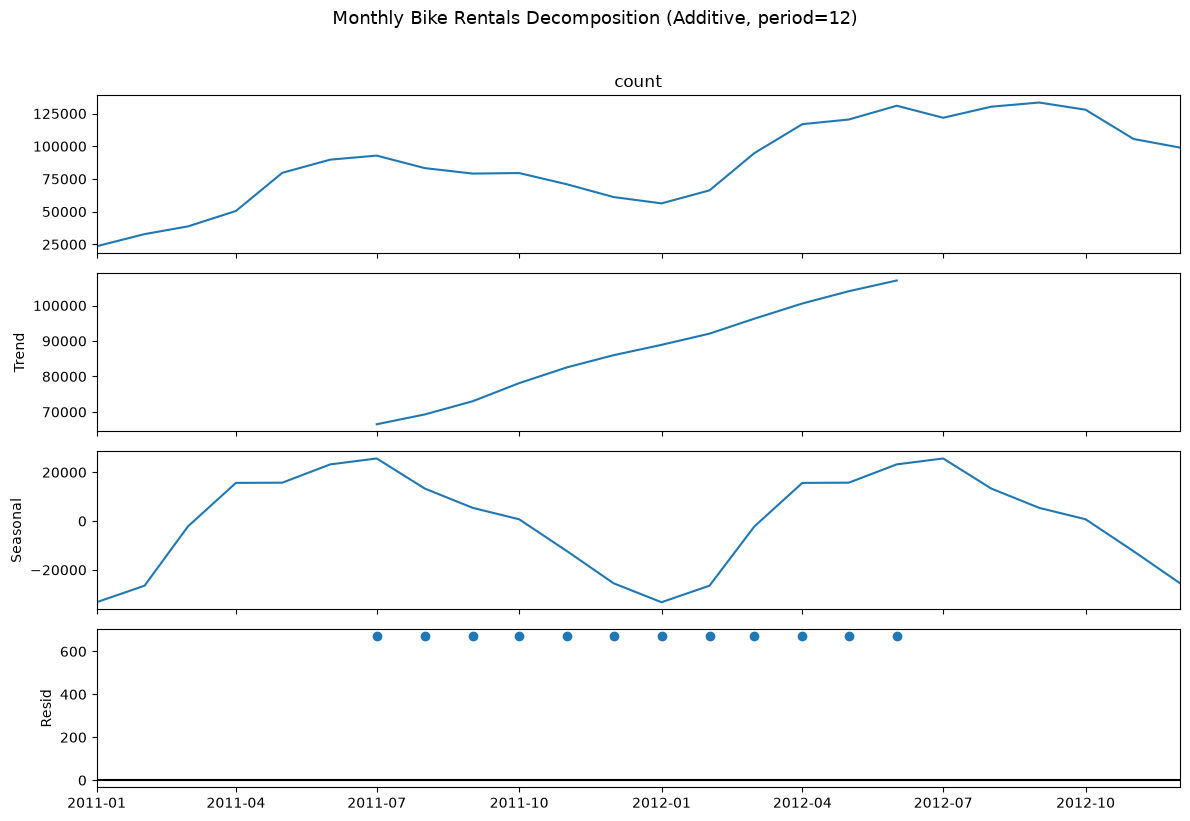

In [7]:
# TODO
# seasonal_decompose()를 이용해 월별 count를 분해해보세요.
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. monthly의 month를 DatetimeIndex로 설정 및 정렬
monthly_df = monthly.copy()
monthly_df["month"] = pd.to_datetime(monthly_df["month"])
monthly_df = monthly_df.set_index("month").sort_index()

# 2. 덧셈 분해(additive) 및 1년 주기(period=12) 적용
decomp = seasonal_decompose(
    monthly_df["count"], model="additive", period=12
)

# 3. 4개 구성요소(Observed, Trend, Seasonal, Residual) 시각화
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.suptitle(
    "Monthly Bike Rentals Decomposition (Additive, period=12)",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.show()

### Q2. 다음 설명을 각각 Trend / Seasonality / Residual과 연결하세요.

- 시간이 지나면서 나타나는 장기적인 증가 또는 감소 
- 일정한 시간 간격을 두고 반복되는 변화
- 추세와 계절성을 제외하고 남은 변동

**답변:**  
- Trend: 시간이 지나면서 나타나는 장기적인 증가 또는 감소 
- Seasonality: 일정한 시간 간격을 두고 반복되는 변화
- Residual: 추세와 계절성을 제외하고 남은 변동

---

# 필수 2. 정상성 진단과 1차 차분

## 배경

정상성은 시간이 지나도 시계열의 **평균적인 수준과 변동의 특성이 크게 달라지지 않는 성질**입니다.

이번 문제에서는 일별 전체 대여량 `count`의 이동평균을 확인하고, ADF Test를 이용해 정상성을 판단합니다. 정상성을 만족한다고 보기 어렵다면 1차 차분을 수행한 뒤 다시 ADF Test를 진행합니다.

## 문제 1. 이동평균으로 평균 수준의 변화를 확인하세요.

### 요구사항

1. `daily["count"]`의 최근 7개 값 이동평균을 계산하여 `rolling_mean` 컬럼에 저장합니다.
2. 원본 `count`와 `rolling_mean`을 같은 그래프에 나타냅니다.
3. 이동평균이 시간에 따라 변하는지 확인합니다.

### 확인 포인트

- `rolling(window=7).mean()`을 사용했는가?
- 이동평균이 개별 값의 작은 변동을 줄여 전체 수준을 보기 위한 방법임을 이해했는가?

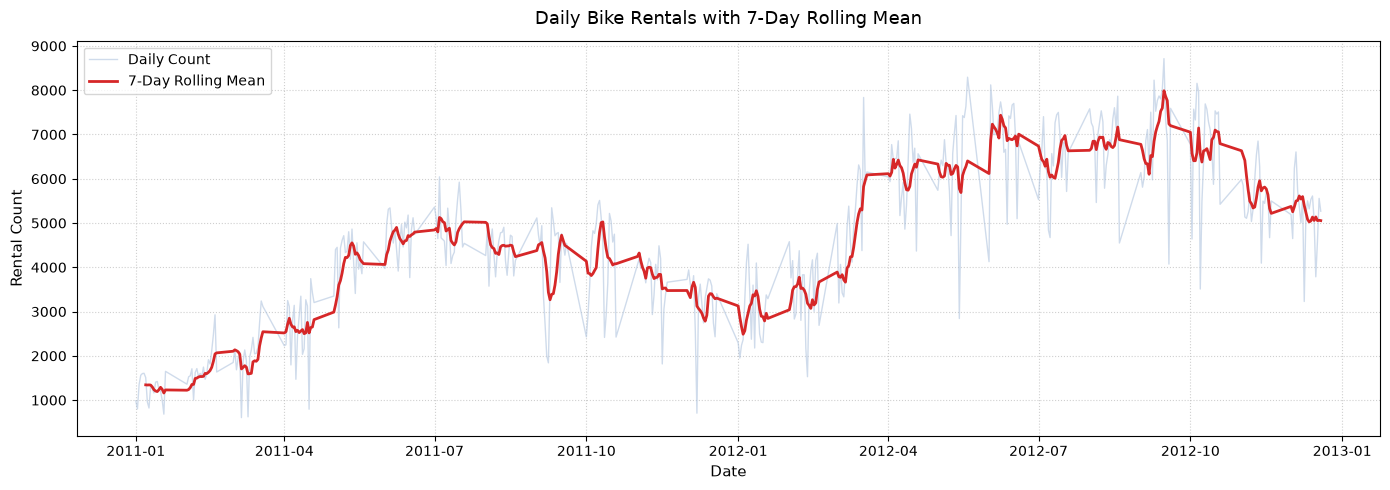

In [8]:
# TODO
# 7개 값 이동평균을 계산하고 원본 count와 함께 시각화하세요.
import matplotlib.pyplot as plt
import pandas as pd

# 1. date 컬럼 정렬 및 7일 이동평균 계산
daily = daily.sort_values("date").reset_index(drop=True)
daily["rolling_mean"] = daily["count"].rolling(window=7).mean() #window=n 구간지정(n개행 전)

# 2. 원본 count와 7일 이동평균 동시 시각화
plt.figure(figsize=(14, 5))
plt.plot(
    daily["date"],
    daily["count"],
    color="lightsteelblue",
    alpha=0.6,
    linewidth=1.0,
    label="Daily Count",
)
plt.plot(
    daily["date"],
    daily["rolling_mean"],
    color="tab:red",
    linewidth=2.0,
    label="7-Day Rolling Mean",
)
plt.title("Daily Bike Rentals with 7-Day Rolling Mean", fontsize=13, pad=12)
plt.xlabel("Date", fontsize=11)
plt.ylabel("Rental Count", fontsize=11)
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

- 이동평균: 단기 변동을 완화하여 보겠다.
- 시계열 보간 방법 중 하나이다.  (ex.여름철 기온)
- 정상성: 값이 움직이는 중심이 시간에 따라 다르게 나타나는지 이동평균을 통해서 정상성의 가능성을 확인하고자함
- 7일 평균: rolling 이동평균(window=7)이면 최근 7개의 행을 의미 (이 케이스에서는 7일을 의미)

- 해석: 최근 7개의 관측값의 평균은 변동폭이 심한 원본데이터 변동을 완화했지만, 여전히 변동폭의 여파는 남아있다.
- 평균 수준이 일정하지 않음을 확인했기 때문에 정상성을 판단하기에는 추가적인 확인이 필요하다(ADF)

## 문제 2. 원본 일별 대여량에 ADF Test를 수행하세요.

### 요구사항

1. `adfuller()`를 이용해 `daily["count"]`를 검정합니다.
2. ADF Statistic과 p-value를 출력합니다.
3. 유의수준 0.05를 기준으로 정상성을 판단합니다.

### 판단 기준

- `p-value < 0.05` → 귀무가설 기각 → 정상성을 만족한다고 판단
- `p-value ≥ 0.05` → 귀무가설을 기각하지 못함 → 정상성을 만족한다고 보기 어려움

In [9]:
# TODO
# 원본 daily["count"]에 ADF Test를 수행하세요.
from statsmodels.tsa.stattools import adfuller

# 1. 결측치 제외 후 ADF Test 실행
adf_res_raw = adfuller(daily["count"].dropna())

# 2. 통계량 및 p-value 출력
print("=== 원본 daily['count'] ADF Test 결과 ===")
print(f"ADF Statistic : {adf_res_raw[0]:.4f}")
print(f"p-value       : {adf_res_raw[1]:.4f}")

# 3. 정상성 판단
alpha = 0.05
if adf_res_raw[1] < alpha:
    print(f"판정: p-value < {alpha} -> 귀무가설 기각 (정상성 만족)")
else:
    print(
        f"판정: p-value >= {alpha} -> 귀무가설 기각 실패 (비정상 시계열 / 정상성 만족 안 함)"
    )

=== 원본 daily['count'] ADF Test 결과 ===
ADF Statistic : -2.0025
p-value       : 0.2855
판정: p-value >= 0.05 -> 귀무가설 기각 실패 (비정상 시계열 / 정상성 만족 안 함)


C:\Users\power\AppData\Local\Temp\ipykernel_36656\3397288516.py:6: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_res_raw = adfuller(daily["count"].dropna())


- 귀무가설: 시계열에 단위근이 존재한다.
- 대립가설: 시계열에 단위근이 존재하지 않는다.

- ADF -2.00의 의미: 단위근 가설에 대한 증거를 요약한 통계량
- p-value 0.28의 의미: 단위근 귀무가설 아래 현재 통계량 또는 기각 방향으로 더 극단적 통계량 확인

- 해석: 원본 전체 대여량의 ADF 통계량은 약 -2.00, p-value는 약 0.28, 유의수준인 0.05보다 높기 때문에 단위근 귀무가설을 기각하지 못함
- 그래서 앞서 이동평균과 함께 1차 차분을 검토해야함, 단, 날짜 누락으로 한계점은 뚜렷하게 보인다.

### Q3. 원본 데이터의 p-value를 기준으로 정상성을 어떻게 판단할 수 있나요?

**답변:**  
정상성은 시간대가 달라도 일반적으로 예상할 수 있는 특성을 이야기하는데, p-value가 정상성을 만족한다는 귀무가설을 기각하지 못하므로 정상성을 만족하지 못한다.
- 시간의 흐름에 따라 불규칙적으로 변화한다. 

## 문제 3. 1차 차분 후 정상성을 다시 확인하세요.

### 요구사항

1. `.diff()`를 이용해 `daily["count"]`를 1차 차분합니다.
2. 첫 번째 `NaN`은 `dropna()`로 제거합니다.
3. 차분된 값을 선 그래프로 나타냅니다.
4. 차분 데이터에 ADF Test를 다시 수행합니다.
5. 차분 전과 차분 후 p-value를 비교하여 정상성 변화를 설명합니다.

### 확인 포인트

- 차분값이 `현재 값 - 이전 값`이라는 것을 이해했는가?
- 차분 후 데이터의 의미가 **일별 대여량 → 이적 관측일 대비 대여량 변화**로 달라짐을 이해했는가?
- 차분 후 ADF Test를 다시 수행했는가?

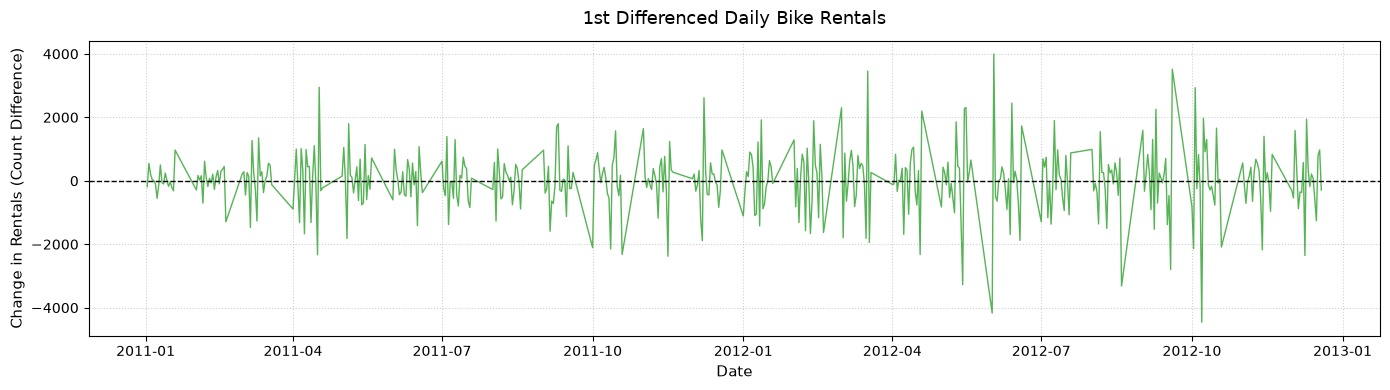

=== 1차 차분 데이터 ADF Test 결과 ===
ADF Statistic : -11.7516
p-value       : 1.2057e-21

=== 차분 전/후 p-value 비교 ===
차분 전 p-value : 0.2855
차분 후 p-value : 1.2057e-21


C:\Users\power\AppData\Local\Temp\ipykernel_36656\842915825.py:24: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_res_diff = adfuller(diff_count)


In [10]:
# TODO
# 1차 차분 → 시각화 → ADF Test 재실행 순서로 진행하세요.
# 1. 1차 차분 계산 및 첫 번째 NaN 결측치 제거
diff_count = daily["count"].diff().dropna()

# 2. 차분 데이터 선 그래프 시각화
plt.figure(figsize=(14, 4))
plt.plot(
    daily.loc[diff_count.index, "date"],
    diff_count,
    color="tab:green",
    linewidth=1.0,
    alpha=0.8,
)
plt.axhline(0, color="black", linestyle="--", linewidth=1.0)
plt.title("1st Differenced Daily Bike Rentals", fontsize=13, pad=12)
plt.xlabel("Date", fontsize=11)
plt.ylabel("Change in Rentals (Count Difference)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# 3. 차분 데이터 대상 ADF Test 재수행
adf_res_diff = adfuller(diff_count)

print("=== 1차 차분 데이터 ADF Test 결과 ===")
print(f"ADF Statistic : {adf_res_diff[0]:.4f}")
print(f"p-value       : {adf_res_diff[1]:.4e}")

# 4. 차분 전/후 비교
print("\n=== 차분 전/후 p-value 비교 ===")
print(f"차분 전 p-value : {adf_res_raw[1]:.4f}")
print(f"차분 후 p-value : {adf_res_diff[1]:.4e}")

- 1차 차분: t(현재시간), t-1(관측 행의 바로 이전 행), 관측행의 순서
- 2011-01-01 현재 대여량 985 이전 대여량 없음 -> 차분값 = Nan
- 2011-01-02 현재 대여량 801 이전 대여량 985 -> 차분값 -184
- -> 이전 관측일보다 184건 감소했다.

### Q4. 차분 전과 차분 후 데이터의 의미는 어떻게 달라지나요?

- 원본 그래프는 대여량 수준이 1000 ~ 9000건 사이에서 크게 움직임
- 차분 그래프는 대여량 수준이 비교적 0에서 대체로 움직임
- -> 차분은 그래프의 변동폭이 일정한가?를 직관적으로 보기 위해 진행


**답변:**  
- 차분 전: 일별 대여량, 추세와 계절성에 따라 평균값 변동
- 차분 후: 전일 대비 대여량의 변동량, 차분을 통해 추세가 제거되어 평균이 0을 중심으로 일정하게 진동하는 정상성을 가진 시계열 데이터.
- 단, 여전히 큰 변동폭들이 남아있고, 누락 날짜가 있기 때문에 추가적으로 변동폭 확인이 필요하다.

---

# 과제 1. 등록 사용자 대여량의 정상성 진단

## 배경

필수 2에서는 전체 대여량 `count`를 이용해 정상성 진단과 차분을 수행했습니다.

이번에는 같은 과정을 **등록 사용자 대여량 `registered`**에 직접 적용합니다.

> 과제는 필수 실습에서 연습한 방법을 동일하게 적용하는 수준입니다.

## 요구사항

1. `daily["registered"]`를 날짜 순서대로 선 그래프로 나타냅니다.
2. 최근 7개 값의 이동평균을 계산하여 원본 데이터와 함께 나타냅니다.
3. 원본 `registered`에 ADF Test를 수행합니다.
4. p-value를 기준으로 정상성을 판단합니다.
5. 정상성을 만족한다고 보기 어렵다면 1차 차분합니다.
6. 1차 차분을 수행한 경우, 차분 데이터에 ADF Test를 다시 수행합니다.
7. 원본과 차분 데이터의 p-value를 근거로 정상성 판단을 설명합니다. 차분하지 않았다면 그 이유를 설명합니다.
8. 진단 결과를 근거로 원본 데이터를 사용할지, 1차 차분한 데이터를 사용할지, 추가 진단이 필요한지 선택하고 이유를 설명합니다.

### 확인 포인트

- 원본 데이터의 시간 흐름을 확인했는가?
- 이동평균으로 평균 수준의 변화를 확인했는가?
- ADF Test의 p-value를 0.05와 비교했는가?
- 필요한 경우 1차 차분 후 ADF Test를 다시 수행했는가?
- 결과를 코드 출력값을 근거로 설명했는가?
- ADF 검정 결과와 그래프를 근거로 이후 모델링 방향을 선택했는가?


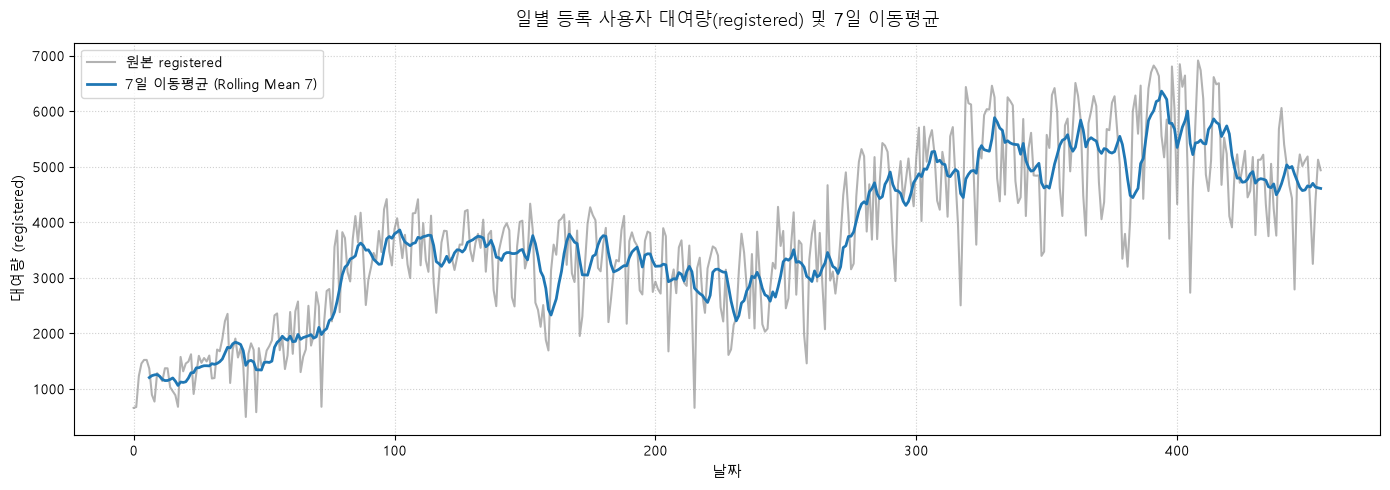

=== 원본 registered ADF Test 결과 ===
ADF Statistic : -1.9070
p-value       : 0.3288

=== 1차 차분 데이터 ADF Test 결과 ===
ADF Statistic : -6.3537
p-value       : 2.5739e-08


C:\Users\power\AppData\Local\Temp\ipykernel_36656\3281977334.py:31: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_orig = adfuller(daily_reg.dropna())
C:\Users\power\AppData\Local\Temp\ipykernel_36656\3281977334.py:40: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_diff = adfuller(diff_reg)


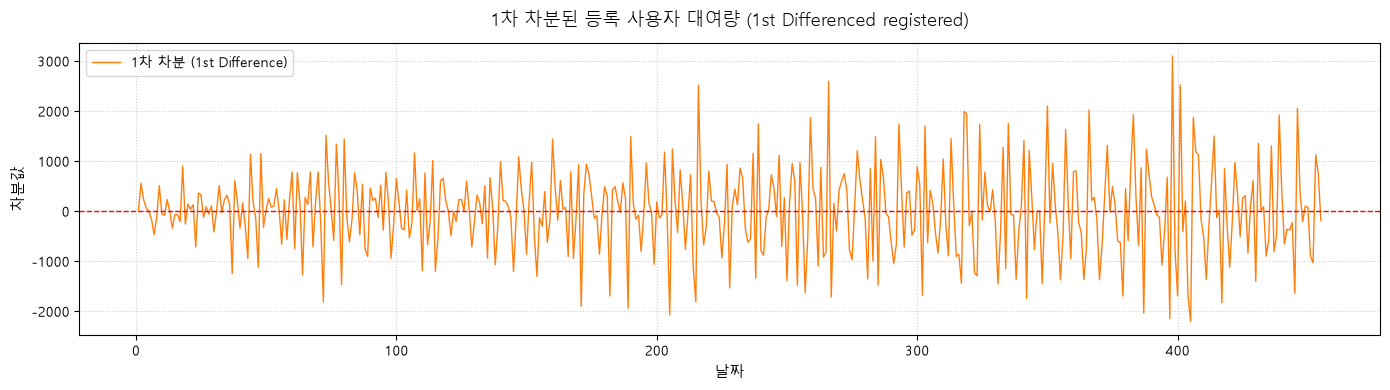

,구분,ADF 통계량,p-value,기각 여부 (p < 0.05),정상성 판정
0,원본 registered,-1.9070,3.2879e-01,False,비정상 (Non-stationary)
1,1차 차분 registered,-6.3537,2.5739e-08,True,정상 (Stationary)


In [13]:
# TODO
# 시각화 → 최근 7개 값 이동평균 → 원본 ADF Test
# → 필요 시 1차 차분 및 ADF Test 재실행 → 결과 비교
# Q5·Q6에는 출력값과 그래프를 근거로 해석과 모델링 방향을 작성하세요.
import matplotlib.pyplot as plt
plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False
# 출처: https://giveme-happyending.tistory.com/168 [소연의_개발일지:티스토리]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# 1~2. 7일 이동평균 계산 및 시각화
daily_reg = daily["registered"].copy()
rolling_mean_7 = daily_reg.rolling(window=7).mean()

plt.figure(figsize=(14, 5))
plt.plot(daily_reg.index, daily_reg, label="원본 registered", color="gray", alpha=0.6)
plt.plot(daily_reg.index, rolling_mean_7, label="7일 이동평균 (Rolling Mean 7)", color="tab:blue", linewidth=2)
plt.title("일별 등록 사용자 대여량(registered) 및 7일 이동평균", fontsize=13, pad=12)
plt.xlabel("날짜", fontsize=11)
plt.ylabel("대여량 (registered)", fontsize=11)
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# 3~4. 원본 데이터 ADF Test 수행
adf_orig = adfuller(daily_reg.dropna())
p_val_orig = adf_orig[1]

print("=== 원본 registered ADF Test 결과 ===")
print(f"ADF Statistic : {adf_orig[0]:.4f}")
print(f"p-value       : {p_val_orig:.4f}")

# 5~6. 정상성 미달(p-value >= 0.05) 시 1차 차분 및 ADF Test 재수행
diff_reg = daily_reg.diff().dropna()
adf_diff = adfuller(diff_reg)
p_val_diff = adf_diff[1]

print("\n=== 1차 차분 데이터 ADF Test 결과 ===")
print(f"ADF Statistic : {adf_diff[0]:.4f}")
print(f"p-value       : {p_val_diff:.4e}")

# 1차 차분 데이터 시각화
plt.figure(figsize=(14, 4))
plt.plot(diff_reg.index, diff_reg, label="1차 차분 (1st Difference)", color="tab:orange", linewidth=1)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title("1차 차분된 등록 사용자 대여량 (1st Differenced registered)", fontsize=13, pad=12)
plt.xlabel("날짜", fontsize=11)
plt.ylabel("차분값", fontsize=11)
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# 7. ADF 결과 요약 비교표
adf_compare_df = pd.DataFrame({
    "구분": ["원본 registered", "1차 차분 registered"],
    "ADF 통계량": [adf_orig[0], adf_diff[0]],
    "p-value": [p_val_orig, p_val_diff],
    "기각 여부 (p < 0.05)": [p_val_orig < 0.05, p_val_diff < 0.05],
    "정상성 판정": ["비정상 (Non-stationary)" if p_val_orig >= 0.05 else "정상 (Stationary)",
                "정상 (Stationary)" if p_val_diff < 0.05 else "비정상 (Non-stationary)"]
})
display(adf_compare_df.style.format({"ADF 통계량": "{:.4f}", "p-value": "{:.4e}"}))

### Q5. 원본 등록 사용자 대여량의 ADF 검정 결과를 어떻게 해석할 수 있나요? 차분했다면 차분 전후 결과를 비교하고, 차분하지 않았다면 그 이유를 설명하세요.

**답변:**
- p-value 0.3288로, 0.05보다 크다. 정상성을 만족하지 못한다는 귀무가설을 기각하지 못한다.
- 1차 차분 후에는 p-value가 0.05보다 매우 작아, 정상성을 만족하지 못한다는 귀무가설을 기각하고, 정상성을 만족한다고 판단할 수 있다.

### Q6. 이후 시계열 모델링에서는 원본 데이터 사용, 1차 차분 데이터 사용, 추가 진단 중 어떤 방향을 선택하겠나요? ADF 검정 결과와 그래프를 근거로 설명하세요.

**답변:**
- 원본, 1차 차분, 추가 진단 모두 보아야한다. 원본으로 파악이 안되면 1차 차분하여 추세를 파악하고, 추가 진단하여 계절성을 파악하고자 한다.


---

# 실습 마무리

아래 질문에 짧게 답해보세요.

1. 시계열 데이터에서 시간 순서가 중요한 이유는 무엇인가요?
2. Trend와 Seasonality의 차이는 무엇인가요?
3. ADF Test에서 `p-value ≥ 0.05`라면 어떻게 해석하나요?
4. 1차 차분은 어떤 값을 계산하나요?
5. 차분 후 ADF Test를 다시 수행해야 하는 이유는 무엇인가요?